**Predicting climate linked vector borne disease outbreaks**

**EDA**

#**First Dataset**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/Outbreaks.csv')

In [5]:
df.head()

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
0,1,Afghanistan,AF,AFG,2000,Arthropod-borne viral fevers and viral haemorr...,Unspecified viral haemorrhagic fever,Unspecified viral haemorrhagic fever,A92-A99,A99,A990,1,D86,1D86,Certain infectious or parasitic diseases,Certain other viral diseases,"Viral haemorrhagic fever, not elsewhere classi...",Unspecified viral haemorrhagic fever,"DON0404, DON0399",NaN
1,2,Afghanistan,AF,AFG,2002,Intestinal infectious diseases,Other gastroenteritis and colitis of infectiou...,Other and unspecified gastroenteritis and coli...,A00-A09,A09,A090,1,A40,1A40,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Gastroenteritis or colitis without specificati...,Infectious gastroenteritis or colitis without ...,DON0607,NaN
2,3,Afghanistan,AF,AFG,1998,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,"DON0253, DON0249, DON0248",Intestinal infection due to Vibrio cholerae
3,4,Afghanistan,AF,AFG,1999,Codes for special purposes,Provisional assignment of new diseases of unce...,Severe acute respiratory syndrome [SARS],U00-U49,U04,U049,1,D65,1D65,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Severe acute respiratory syndrome,Severe acute respiratory syndrome,DON0294,"A disease of the respiratory system, caused by..."
4,5,Afghanistan,AF,AFG,2000,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,DON0413,Intestinal infection due to Vibrio cholerae


In [6]:
df.shape

(2227, 20)

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Country,0
iso2,4
iso3,0
Year,0
icd10n,0
icd103n,0
icd104n,0
icd10c,0
icd103c,0


In [8]:
null_iso2 = df[df['iso2'].isnull()]
null_iso2

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
953,954,Namibia,NaN,NAM,2018,Viral hepatitis,Other acute viral hepatitis,Acute hepatitis E,B15-B19,B17,B172,1,E50,1.00E+50,Certain infectious or parasitic diseases,Viral hepatitis,Acute viral hepatitis,Acute hepatitis E,DON2391,"A disease of the liver, caused by an acute inf..."
954,955,Namibia,NaN,NAM,2009,Influenza and pneumonia,Influenza due to identified zoonotic or pandem...,Influenza due to identified zoonotic or pandem...,J09-J18,J09,J090,1,E31,1.00E+31,Certain infectious or parasitic diseases,Influenza,Influenza,Influenza due to identified zoonotic or pande...,DON1437,"Influenza, caused by influenza virus strains o..."
955,956,Namibia,NaN,NAM,2006,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",A80-A89,A80,A809,1,C81,1C81,Certain infectious or parasitic diseases,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",DON1128,"A disease of the nervous system, caused by hum..."
956,957,Namibia,NaN,NAM,1999,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",A20-A28,A20,A209,1,B93,1B93,Certain infectious or parasitic diseases,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",DON0325,A disease caused by an infection with the gram...


In [9]:
values_to_fill={'iso2':'NM'}
df.fillna(value=values_to_fill,inplace=True)

In [10]:
df[df['Country'] == 'Namibia']

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
953,954,Namibia,NM,NAM,2018,Viral hepatitis,Other acute viral hepatitis,Acute hepatitis E,B15-B19,B17,B172,1,E50,1.00E+50,Certain infectious or parasitic diseases,Viral hepatitis,Acute viral hepatitis,Acute hepatitis E,DON2391,"A disease of the liver, caused by an acute inf..."
954,955,Namibia,NM,NAM,2009,Influenza and pneumonia,Influenza due to identified zoonotic or pandem...,Influenza due to identified zoonotic or pandem...,J09-J18,J09,J090,1,E31,1.00E+31,Certain infectious or parasitic diseases,Influenza,Influenza,Influenza due to identified zoonotic or pande...,DON1437,"Influenza, caused by influenza virus strains o..."
955,956,Namibia,NM,NAM,2006,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",A80-A89,A80,A809,1,C81,1C81,Certain infectious or parasitic diseases,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",DON1128,"A disease of the nervous system, caused by hum..."
956,957,Namibia,NM,NAM,1999,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",A20-A28,A20,A209,1,B93,1B93,Certain infectious or parasitic diseases,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",DON0325,A disease caused by an infection with the gram...


In [11]:
null_icd11l2 = df[df['icd11l2'].isnull()]
null_icd11l2

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
8,9,Afghanistan,AF,AFG,1999,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON0291,NaN
29,30,Angola,AO,AGO,2007,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified","DON1258, DON1257",NaN
43,44,Angola,AO,AGO,2011,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON1598,NaN
200,201,Cambodia,KH,KHM,2012,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified","DON1648, DON1651, DON1650",NaN
401,402,Congo Democratic Republic of the,CD,COD,2007,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON1236,NaN
838,839,Liberia,LR,LBR,2017,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON2327,NaN
883,884,Malaysia,MY,MYS,1997,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified","DON0167, DON0161, DON0162, DON0166, DON0164",NaN
938,939,Mozambique,MZ,MOZ,1998,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON0277,NaN
1263,1264,South Africa,ZA,ZAF,2008,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON1329,NaN
1292,1293,Sri Lanka,LK,LKA,2005,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON0946,NaN


In [12]:
df = df.fillna({'icd11l2': 'Unknown', 'icd11l3': 'Unknown'})

In [13]:
df['Definition'] = df['Definition'].fillna('Not specified')


In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
Country,0
iso2,0
iso3,0
Year,0
icd10n,0
icd103n,0
icd104n,0
icd10c,0
icd103c,0


In [15]:
print(df.describe(include=['object']))

                                 Country  iso2  iso3  \
count                               2227  2227  2227   
unique                               233   233   233   
top     Congo Democratic Republic of the    CD   COD   
freq                                  57    57    57   

                                                   icd10n  \
count                                                2227   
unique                                                 20   
top     Provisional assignment of new diseases of unce...   
freq                                                  732   

                     icd103n                     icd104n   icd10c icd103c  \
count                   2227                        2227     2227    2227   
unique                    50                          70       19      49   
top     Emergency use of U07  COVID-19, virus identified  U00-U49     U07   
freq                     665                         665      764     665   

       icd104c icd11c1 icd1

In [16]:
country_counts = df['Country'].value_counts().head(10)
print(country_counts)

Country
Congo Democratic Republic of the    57
Nigeria                             44
United States of America            37
Sudan                               32
Chad                                31
China                               31
Brazil                              31
France                              28
Burkina Faso                        28
Niger                               28
Name: count, dtype: int64


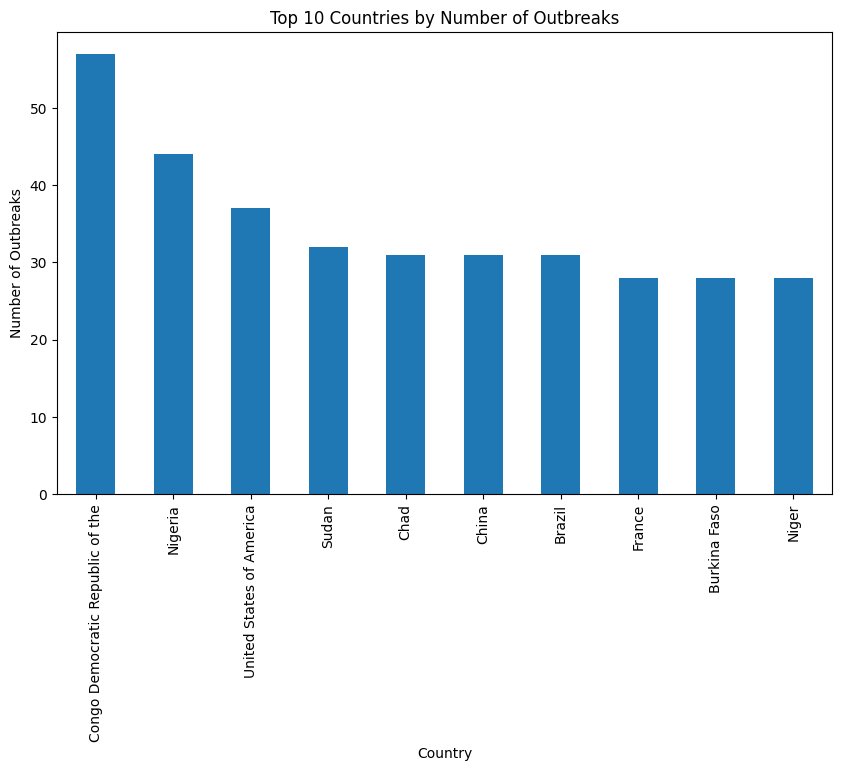

In [17]:
plt.figure(figsize=(10,6))
country_counts.plot(kind='bar')
plt.title("Top 10 Countries by Number of Outbreaks")
plt.xlabel("Country")
plt.ylabel("Number of Outbreaks")
plt.show()

In [18]:
disease_counts = df['Disease'].value_counts().head(10)
print(disease_counts)

Disease
COVID-19                                                             665
 Influenza due to identified zoonotic or pandemic influenza virus    409
Cholera                                                              167
Acute poliomyelitis, unspecified                                     112
Yellow fever, unspecified                                            104
Meningococcal meningitis                                              95
Measles                                                               83
Middle East respiratory syndrome                                      67
Dengue fever, unspecified                                             50
Unspecified viral haemorrhagic fever                                  49
Name: count, dtype: int64


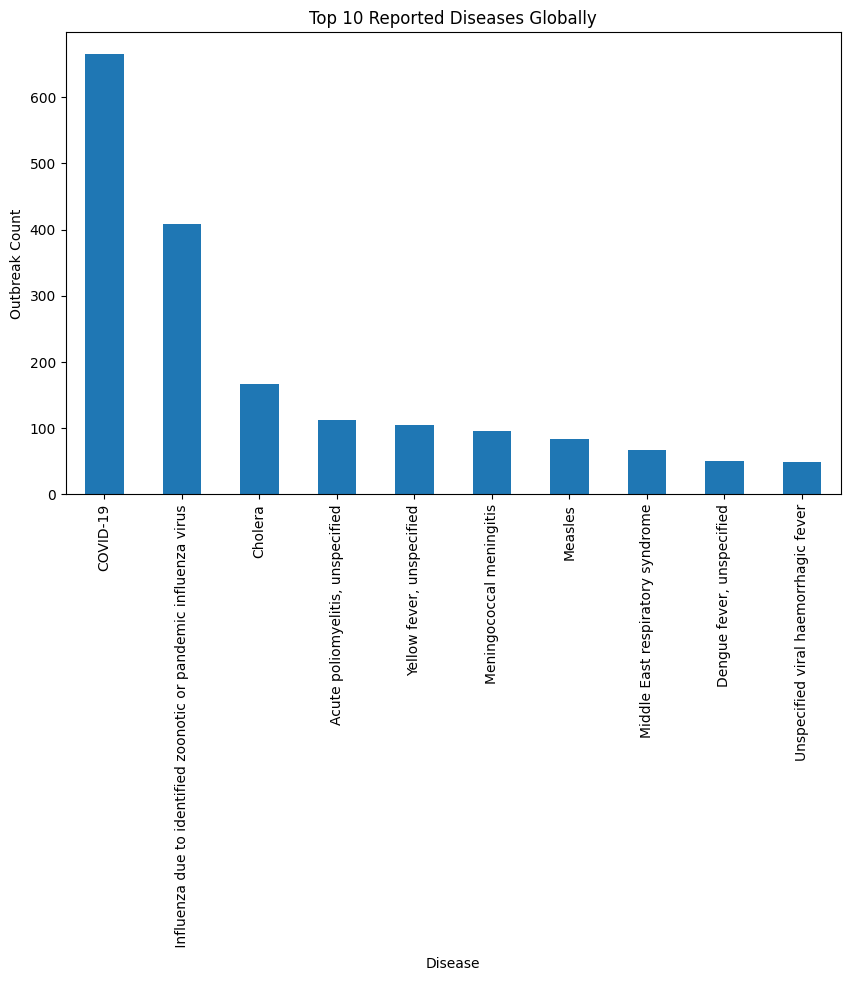

In [19]:
plt.figure(figsize=(10,6))
disease_counts.plot(kind='bar')
plt.title("Top 10 Reported Diseases Globally")
plt.xlabel("Disease")
plt.ylabel("Outbreak Count")
plt.show()


In [20]:
yearly_counts = df['Year'].value_counts().sort_index()
print(yearly_counts)

Year
1996     78
1997     42
1998     86
1999     67
2000     40
2001     49
2002     36
2003     83
2004     73
2005     40
2006     43
2007     29
2008     48
2009    207
2010     73
2011     48
2012     33
2013     33
2014     40
2015     57
2016     58
2017     57
2018     43
2019     95
2020    257
2021    275
2022    237
Name: count, dtype: int64


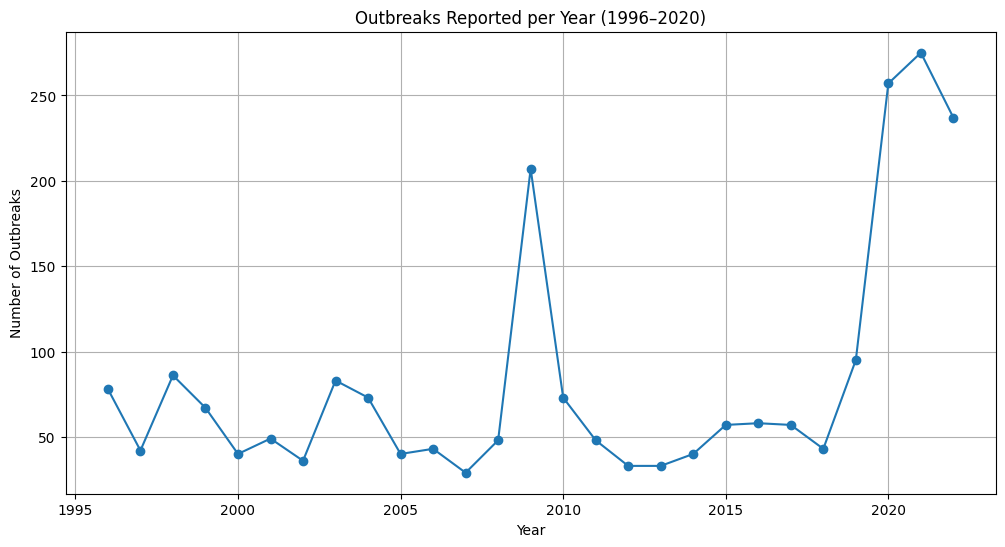

In [21]:
plt.figure(figsize=(12,6))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title("Outbreaks Reported per Year (1996–2020)")
plt.xlabel("Year")
plt.ylabel("Number of Outbreaks")
plt.grid(True)
plt.show()

In [22]:
top_years_with_most_outbreaks = df['Year'].value_counts().sort_values(ascending=False).head(10)
print(top_years_with_most_outbreaks)

Year
2021    275
2020    257
2022    237
2009    207
2019     95
1998     86
2003     83
1996     78
2004     73
2010     73
Name: count, dtype: int64


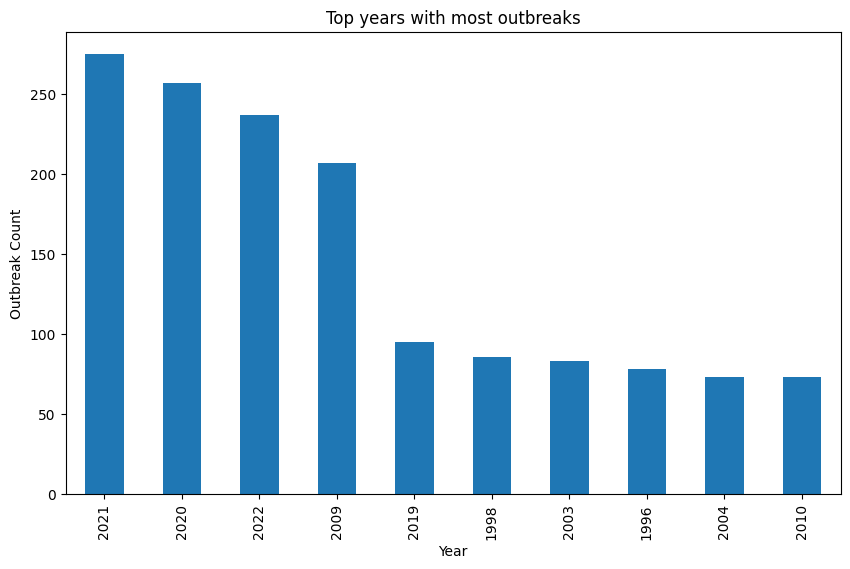

In [23]:
plt.figure(figsize=(10,6))
top_years_with_most_outbreaks.plot(kind='bar')
plt.title("Top years with most outbreaks")
plt.xlabel("Year")
plt.ylabel("Outbreak Count")
plt.show()

In [24]:
print(df['icd11l1'].value_counts().head(10))
print(df['icd11l2'].value_counts().head(10))
print(df['icd11l3'].value_counts().head(10))


icd11l1
Certain infectious or parasitic diseases      1545
Codes for special purposes                     665
Extension Codes                                 14
Diseases of the respiratory system               2
Diseases of the nervous system                   1
Name: count, dtype: int64
icd11l2
International provisional assignment of new diseases of uncertain aetiology and emergency use    665
Influenza                                                                                        409
Gastroenteritis or colitis of infectious origin                                                  198
Certain arthropod-borne viral fevers                                                             197
Certain zoonotic viral diseases                                                                  175
Viral infections of the central nervous system                                                   163
Other bacterial diseases                                                                         

In [25]:
df['Country'].value_counts()

,count
Country,
Congo Democratic Republic of the,57
Nigeria,44
United States of America,37
Sudan,32
Chad,31
...,...
Macao,1
Nauru,1
Tuvalu,1


In [26]:
df['Disease'].value_counts()

,count
Disease,
COVID-19,665
Influenza due to identified zoonotic or pandemic influenza virus,409
Cholera,167
"Acute poliomyelitis, unspecified",112
"Yellow fever, unspecified",104
...,...
"Coccidioidomycosis, unspecified",1
Tuberculosis of the respiratory system,1
Haemorrhagic fever with renal syndrome,1


#**Second dataset**

In [27]:
  c_df=pd.read_csv('/content/update_temperature.csv')
  c_df.head()

,Year,Country,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct
0,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1
1,2000,China,12.8,2.7,0,645,1267000000,16.5,24,18.8
2,2000,Germany,9.3,10.1,0,700,82200000,6.6,12,31.8
3,2000,Brazil,24.9,1.9,0,1760,175000000,83.7,18,65.4
4,2000,Australia,21.7,17.2,0,534,19200000,8.8,11,16.2


In [28]:
c_df.describe()

,Year,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct
count,156.000000,156.000000,156.000000,156.000000,156.000000,1.560000e+02,156.000000,156.000000,156.000000
mean,2012.333333,17.620513,7.673718,24.333333,937.397436,2.952075e+08,31.203846,20.185897,32.191667
std,8.326664,7.221658,5.450198,16.916239,532.954803,4.414786e+08,26.741843,10.951980,18.335613
min,2000.000000,5.100000,0.500000,0.000000,54.000000,1.915300e+07,0.000000,2.000000,0.500000
25%,2005.000000,12.800000,2.175000,10.000000,576.000000,5.448750e+07,14.850000,12.750000,17.225000
50%,2012.500000,15.500000,7.350000,23.500000,775.500000,1.230873e+08,19.800000,18.000000,32.000000
75%,2020.000000,25.225000,10.800000,36.000000,1151.750000,2.132000e+08,43.050000,25.000000,48.125000
max,2024.000000,28.500000,20.200000,59.000000,2726.000000,1.426000e+09,87.200000,64.000000,68.500000


In [29]:
c_df.isnull().sum()

,0
Year,0
Country,0
Avg_Temperature_degC,0
CO2_Emissions_tons_per_capita,0
Sea_Level_Rise_mm,0
Rainfall_mm,0
Population,0
Renewable_Energy_pct,0
Extreme_Weather_Events,0
Forest_Area_pct,0


In [30]:
c_df['Country'].count()

np.int64(156)

In [31]:

c_df['Country'].value_counts()

,count
Country,
China,12
Germany,12
Brazil,12
Russia,12
Australia,12
India,12
Nigeria,12
United States,6
South Africa,6


In [32]:
c_df.shape

(156, 10)

In [33]:
country_counts = c_df['Country'].value_counts().head(10)
print(country_counts)

Country
China            12
Germany          12
Brazil           12
Russia           12
Australia        12
India            12
Nigeria          12
United States     6
South Africa      6
Canada            6
Name: count, dtype: int64


In [34]:
c_df.columns

Index(['Year', 'Country', 'Avg_Temperature_degC',
       'CO2_Emissions_tons_per_capita', 'Sea_Level_Rise_mm', 'Rainfall_mm',
       'Population', 'Renewable_Energy_pct', 'Extreme_Weather_Events',
       'Forest_Area_pct'],
      dtype='object')

In [35]:
avg_temp_trend=c_df.groupby('Year')['Avg_Temperature_degC'].mean()
avg_temp_trend

,Avg_Temperature_degC
Year,
2000,17.000000
2005,17.211538
2010,17.411538
2015,17.746154
2020,18.053846
2024,18.300000


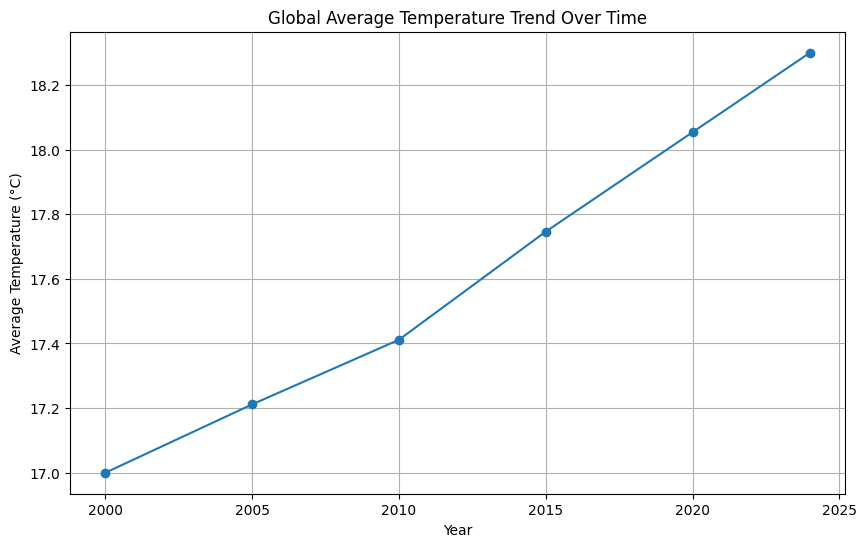

In [36]:
plt.figure(figsize=(10,6))
avg_temp_trend.plot(marker='o')
plt.title("Global Average Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

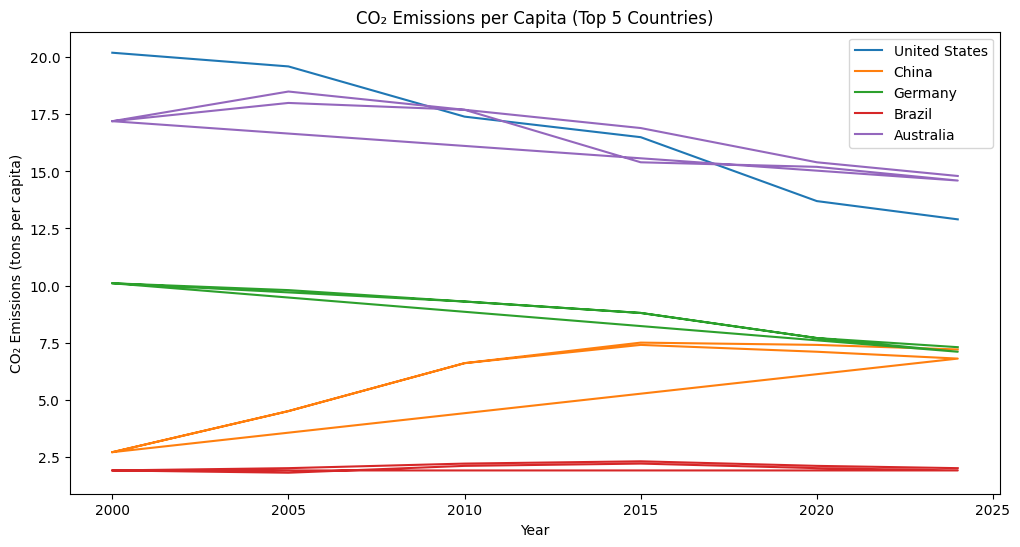

In [37]:
plt.figure(figsize=(12,6))
for country in c_df['Country'].unique()[:5]:
    subset = c_df[c_df['Country'] == country]
    plt.plot(subset['Year'], subset['CO2_Emissions_tons_per_capita'], label=country)
plt.title("CO₂ Emissions per Capita (Top 5 Countries)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (tons per capita)")
plt.legend()
plt.show()

In [38]:
sea_level_trend=c_df.groupby('Year')['Sea_Level_Rise_mm'].mean()
sea_level_trend

,Sea_Level_Rise_mm
Year,
2000,0.000000
2005,10.076923
2010,19.846154
2015,29.384615
2020,39.576923
2024,47.115385


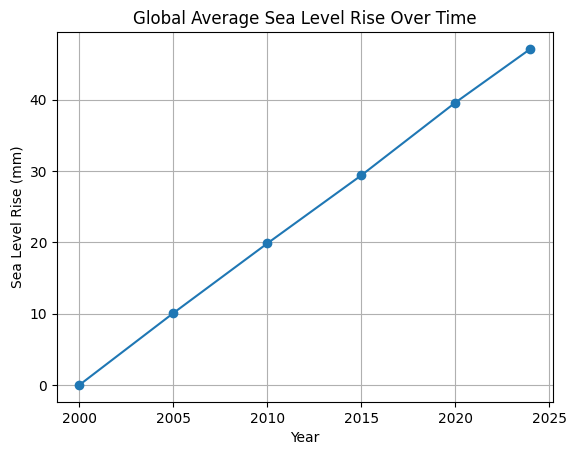

In [39]:
sea_level_trend.plot(kind='line', marker='o')
plt.title("Global Average Sea Level Rise Over Time")
plt.xlabel("Year")
plt.ylabel("Sea Level Rise (mm)")
plt.grid(True)
plt.show()

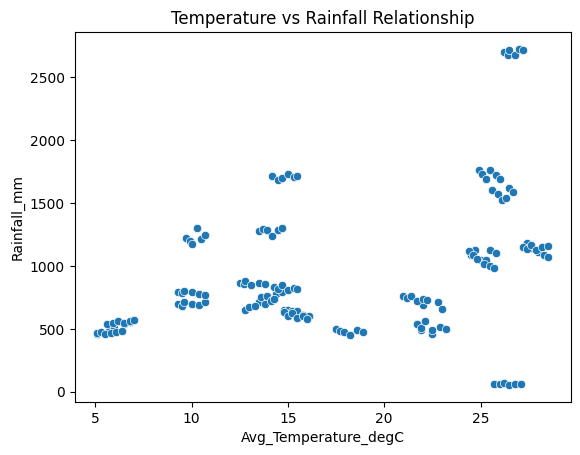

In [40]:
sns.scatterplot(x='Avg_Temperature_degC', y='Rainfall_mm', data=c_df)
plt.title("Temperature vs Rainfall Relationship")
plt.show()

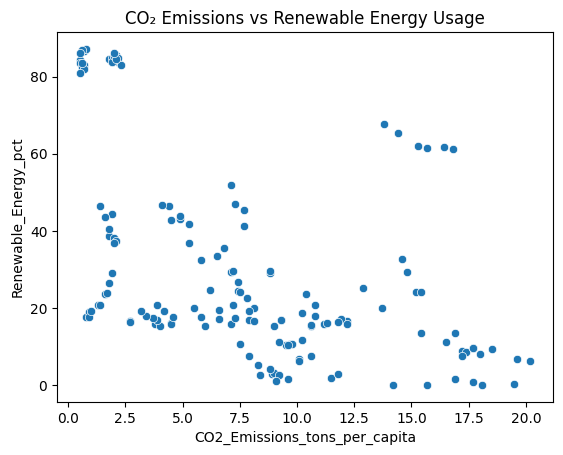

In [41]:
sns.scatterplot(x='CO2_Emissions_tons_per_capita', y='Renewable_Energy_pct', data=c_df)
plt.title("CO₂ Emissions vs Renewable Energy Usage")
plt.show()

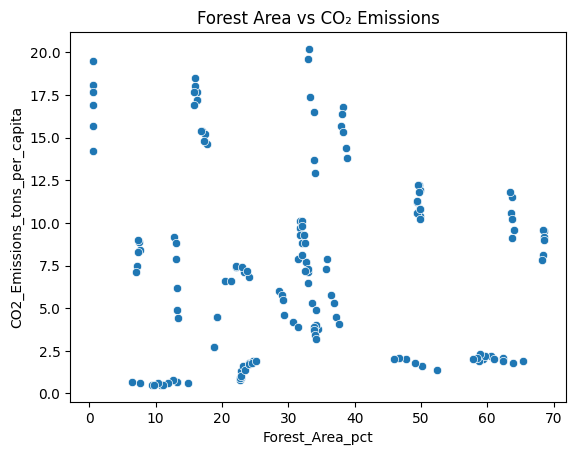

In [42]:
sns.scatterplot(x='Forest_Area_pct', y='CO2_Emissions_tons_per_capita', data=c_df)
plt.title("Forest Area vs CO₂ Emissions")
plt.show()

In [43]:
hottest_countries=c_df.groupby('Country')['Avg_Temperature_degC'].mean().sort_values(ascending=False).head(10)
hottest_countries

,Avg_Temperature_degC
Country,
Nigeria,27.816667
Indonesia,26.683333
Saudi Arabia,26.383333
Brazil,25.808333
India,25.083333
Australia,22.350000
Mexico,21.583333
South Africa,18.133333
Spain,15.383333


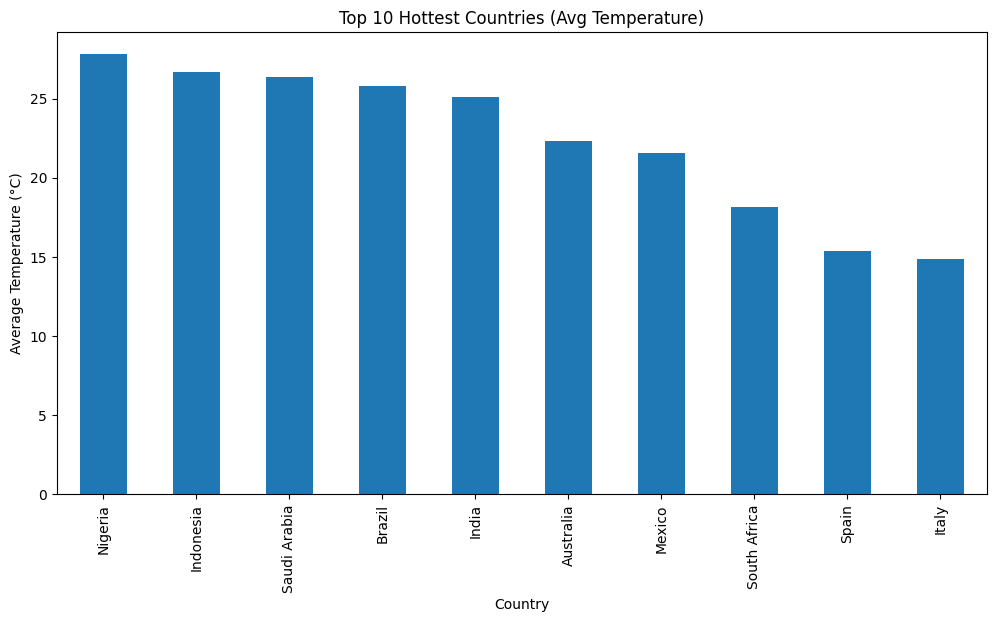

In [44]:
plt.figure(figsize=(12,6))
hottest_countries.plot(kind='bar')
plt.title("Top 10 Hottest Countries (Avg Temperature)")
plt.ylabel("Average Temperature (°C)")
plt.show()

In [45]:
renewable_country_usage=c_df.groupby('Country')['Renewable_Energy_pct'].mean().sort_values(ascending=False).head(10)
renewable_country_usage

,Renewable_Energy_pct
Country,
Brazil,84.458333
Nigeria,84.050000
Canada,63.250000
Indonesia,40.400000
Spain,32.533333
Italy,28.833333
Germany,25.900000
India,24.975000
China,22.550000


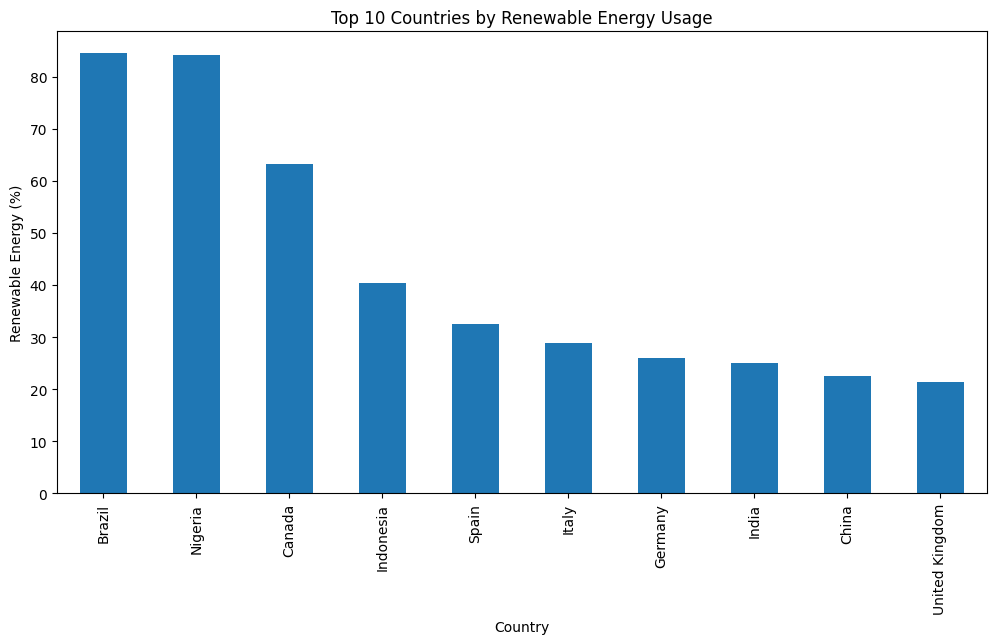

In [46]:
plt.figure(figsize=(12,6))
renewable_country_usage.plot(kind='bar')
plt.title("Top 10 Countries by Renewable Energy Usage")
plt.ylabel("Renewable Energy (%)")
plt.show()

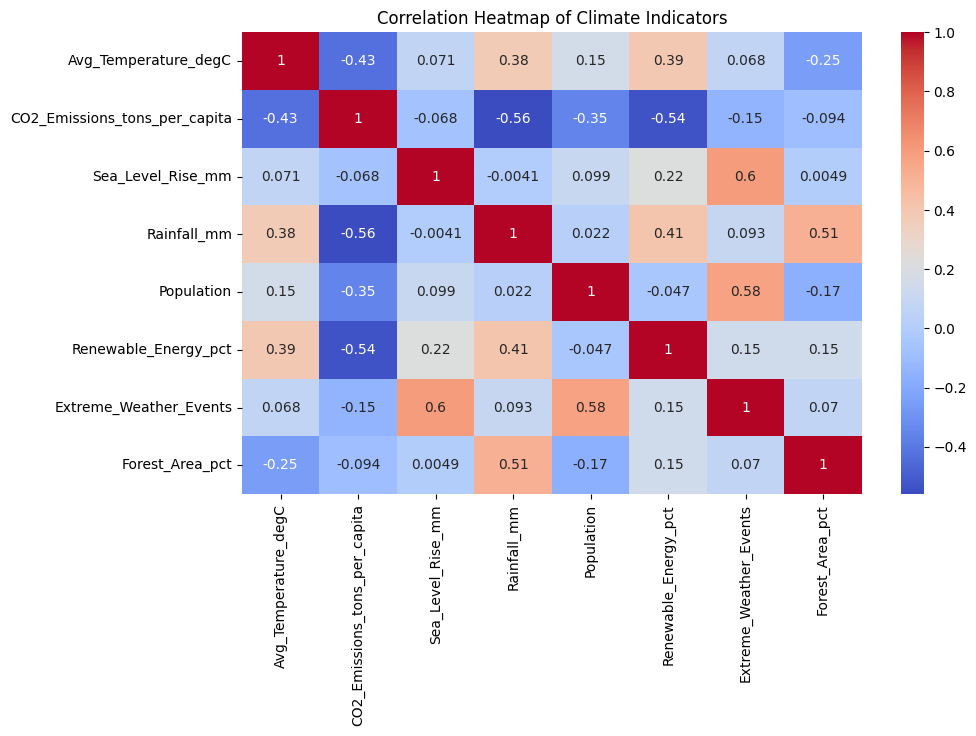

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(c_df[['Avg_Temperature_degC','CO2_Emissions_tons_per_capita',
                        'Sea_Level_Rise_mm','Rainfall_mm','Population',
                        'Renewable_Energy_pct','Extreme_Weather_Events','Forest_Area_pct']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Climate Indicators")
plt.show()

In [48]:
exreeme_weather_events=c_df.groupby('Year')['Extreme_Weather_Events'].sum()
exreeme_weather_events

,Extreme_Weather_Events
Year,
2000,336
2005,399
2010,465
2015,544
2020,656
2024,749


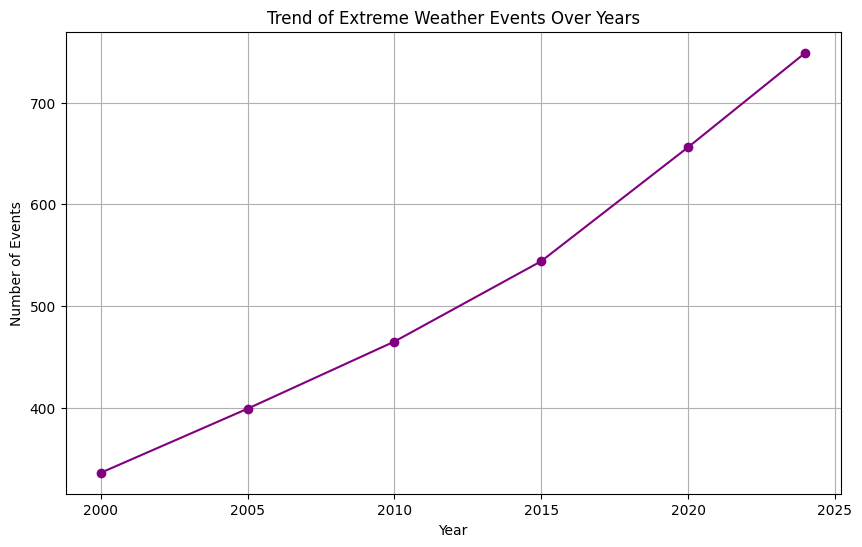

In [49]:
plt.figure(figsize=(10,6))
exreeme_weather_events.plot(kind='line', marker='o', color='purple')
plt.title("Trend of Extreme Weather Events Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.grid(True)
plt.show()

#**Models**

In [50]:
!pip install pycountry
import pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 56.3 MB/s eta 0:00:00


In [51]:
def standardize_country(name):
    try:
        return pycountry.countries.lookup(name).name
    except:
        return name  # keep original if not found

df['Country'] = df['Country'].apply(standardize_country)
c_df['Country'] = c_df['Country'].apply(standardize_country)


In [52]:
merged_df = c_df.merge(df, on=["Country", "Year"], how="left")
merged_df["Outbreak_Flag"] = np.where(merged_df["Disease"].notna(), 1, 0)

In [53]:
merged_df.head()

,Year,Country,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct,...,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition,Outbreak_Flag
0,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1,...,1,B91,1B91,Certain infectious or parasitic diseases,Certain zoonotic bacterial diseases,Leptospirosis,"Leptospirosis, unspecified",DON0414,A disease caused by an infection with the gram...,1
1,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1,...,1,C1C,1C1C,Certain infectious or parasitic diseases,Other bacterial diseases,Meningococcal disease,Meningococcal meningitis,DON0391,"A condition of the meninges, caused by an infe...",1
2,2000,China,12.8,2.7,0,645,1267000000,16.5,24,18.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2000,Germany,9.3,10.1,0,700,82200000,6.6,12,31.8,...,1,D61,1D61,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Arenavirus disease,Lassa fever,"DON0385, DON0365, DON0367",A disease endemic in large parts of sub-Sahara...,1
4,2000,Brazil,24.9,1.9,0,1760,175000000,83.7,18,65.4,...,1,D47,1D47,Certain infectious or parasitic diseases,Certain arthropod-borne viral fevers,Yellow fever,"Yellow fever, unspecified","DON0368, DON0366",A condition caused by an infection with yellow...,1


In [54]:
merged_df['Unnamed: 0']

,Unnamed: 0
0,1495.0
1,1505.0
2,NaN
3,573.0
4,133.0
...,...
183,1052.0
184,1039.0
185,1042.0
186,1999.0


In [55]:
merged_df['Unnamed: 0'].head()

,Unnamed: 0
0,1495.0
1,1505.0
2,NaN
3,573.0
4,133.0


In [56]:
df.head()

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
0,1,Afghanistan,AF,AFG,2000,Arthropod-borne viral fevers and viral haemorr...,Unspecified viral haemorrhagic fever,Unspecified viral haemorrhagic fever,A92-A99,A99,A990,1,D86,1D86,Certain infectious or parasitic diseases,Certain other viral diseases,"Viral haemorrhagic fever, not elsewhere classi...",Unspecified viral haemorrhagic fever,"DON0404, DON0399",Not specified
1,2,Afghanistan,AF,AFG,2002,Intestinal infectious diseases,Other gastroenteritis and colitis of infectiou...,Other and unspecified gastroenteritis and coli...,A00-A09,A09,A090,1,A40,1A40,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Gastroenteritis or colitis without specificati...,Infectious gastroenteritis or colitis without ...,DON0607,Not specified
2,3,Afghanistan,AF,AFG,1998,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,"DON0253, DON0249, DON0248",Intestinal infection due to Vibrio cholerae
3,4,Afghanistan,AF,AFG,1999,Codes for special purposes,Provisional assignment of new diseases of unce...,Severe acute respiratory syndrome [SARS],U00-U49,U04,U049,1,D65,1D65,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Severe acute respiratory syndrome,Severe acute respiratory syndrome,DON0294,"A disease of the respiratory system, caused by..."
4,5,Afghanistan,AF,AFG,2000,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,DON0413,Intestinal infection due to Vibrio cholerae


In [58]:
merged_df.shape

(188, 29)

In [59]:
merged_df.isnull().sum()

,0
Year,0
Country,0
Avg_Temperature_degC,0
CO2_Emissions_tons_per_capita,0
Sea_Level_Rise_mm,0
Rainfall_mm,0
Population,0
Renewable_Energy_pct,0
Extreme_Weather_Events,0
Forest_Area_pct,0


In [60]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,188.0,2.012388e+03,8.109760e+00,2000.0,2.005000e+03,2.015000e+03,2.020000e+03,2.024000e+03
Avg_Temperature_degC,188.0,1.792340e+01,7.265697e+00,5.1,1.300000e+01,1.565000e+01,2.550000e+01,2.850000e+01
CO2_Emissions_tons_per_capita,188.0,7.409574e+00,5.513456e+00,0.5,2.100000e+00,7.150000e+00,1.060000e+01,2.020000e+01
Sea_Level_Rise_mm,188.0,2.456915e+01,1.655942e+01,0.0,1.000000e+01,2.600000e+01,3.600000e+01,5.900000e+01
Rainfall_mm,188.0,9.420798e+02,5.227453e+02,54.0,6.027500e+02,7.785000e+02,1.150000e+03,2.726000e+03
Population,188.0,3.197976e+08,4.577992e+08,19153000.0,5.888025e+07,1.273700e+08,2.238012e+08,1.426000e+09
Renewable_Energy_pct,188.0,3.304681e+01,2.784421e+01,0.0,1.530000e+01,2.075000e+01,4.562500e+01,8.720000e+01
Extreme_Weather_Events,188.0,2.057447e+01,1.083221e+01,2.0,1.300000e+01,1.850000e+01,2.600000e+01,6.400000e+01
Forest_Area_pct,188.0,3.138564e+01,1.809861e+01,0.5,1.697500e+01,3.190000e+01,4.065000e+01,6.850000e+01
Unnamed: 0,103.0,9.283981e+02,6.186810e+02,58.0,3.265000e+02,9.140000e+02,1.492000e+03,2.221000e+03


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, log_loss
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [62]:
df = merged_df.copy()

# Drop irrelevant columns
drop_cols = ['Unnamed: 0', 'iso2', 'iso3', 'icd10n', 'icd103n', 'icd104n', 'icd10c',
             'icd103c', 'icd104c', 'icd11c1', 'icd11c2', 'icd11c3', 'icd11l1',
             'icd11l2', 'icd11l3', 'DONs', 'Definition', 'Disease']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

df_majority = df[df.Outbreak_Flag == 1]
df_minority = df[df.Outbreak_Flag == 0]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class Balance After Upsampling:")
print(df_balanced['Outbreak_Flag'].value_counts())

Class Balance After Upsampling:
Outbreak_Flag
1    103
0    103
Name: count, dtype: int64


Columns in X before scaling and feature selection:
Index(['Year', 'Avg_Temperature_degC', 'CO2_Emissions_tons_per_capita',
       'Sea_Level_Rise_mm', 'Rainfall_mm', 'Population',
       'Renewable_Energy_pct', 'Extreme_Weather_Events', 'Forest_Area_pct',
       'Country_Brazil', 'Country_Canada', 'Country_China', 'Country_France',
       'Country_Germany', 'Country_India', 'Country_Indonesia',
       'Country_Italy', 'Country_Japan', 'Country_Korea, Republic of',
       'Country_Mexico', 'Country_Nigeria', 'Country_Russia',
       'Country_Saudi Arabia', 'Country_South Africa', 'Country_Spain',
       'Country_United Kingdom', 'Country_United States'],
      dtype='object')
Top 10 Features by ANOVA F-test:
                          Feature      Score
21                 Country_Russia  23.071429
6            Renewable_Energy_pct  15.540547
1            Avg_Temperature_degC  10.255741
8                 Forest_Area_pct   8.483315
9                  Country_Brazil   7.882535
18     Countr

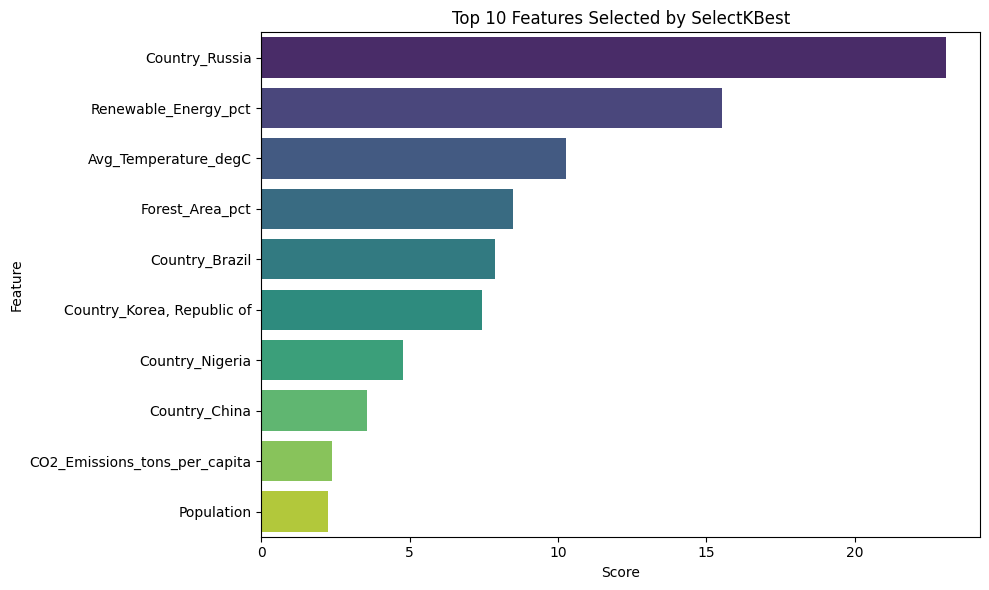

In [63]:
# Separate features
X = df_balanced.drop('Outbreak_Flag', axis=1)
y = df_balanced['Outbreak_Flag']

if len(y.unique()) == 1:
    np.random.seed(42)
    y = np.random.choice([0, 1], size=len(X))
    print("Only one class in y — simulated binary target for testing feature selection")

# Handle categorical variables
X = pd.get_dummies(X, drop_first=True)

# Clean data
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
X = X.loc[:, X.nunique() > 1]

print("Columns in X before scaling and feature selection:")
print(X.columns)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("Top 10 Features by ANOVA F-test:")
print(feature_scores.head(10))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(10), palette='viridis')
plt.title("Top 10 Features Selected by SelectKBest")
plt.tight_layout()
plt.show()


LR

In [64]:
#Feature & Target
X = df_balanced.drop('Outbreak_Flag', axis=1)
y = df_balanced['Outbreak_Flag']

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Feature Selection
selector = SelectKBest(score_func=f_classif, k=min(10, X.shape[1]))
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]

print("Top Selected Features:")
for f in selected_features:
    print(f)

Top Selected Features:
Avg_Temperature_degC
CO2_Emissions_tons_per_capita
Population
Renewable_Energy_pct
Forest_Area_pct
Country_Brazil
Country_China
Country_Korea, Republic of
Country_Nigeria
Country_Russia


In [65]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize SGDClassifier
sgd = SGDClassifier(loss='log_loss', random_state=42)

# Define hyperparameter grid
param_grid = {
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],       # Regularization strength
    'max_iter': [1000, 2000, 5000],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.001, 0.01, 0.1]           # Initial learning rate
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Run grid search
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Evaluate on test set
best_sgd = grid_search.best_estimator_
y_pred = best_sgd.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'alpha': 0.01, 'eta0': 0.1, 'learning_rate': 'constant', 'max_iter': 1000, 'penalty': 'l1'}
Best CV Score: 0.6888257575757576
Test Accuracy: 0.6190476190476191

Confusion Matrix:
 [[14  7]
 [ 9 12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.67      0.64        21
           1       0.63      0.57      0.60        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42



In [66]:
# Class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class Weights:", class_weights)

# Initialize SGDClassifier
clf = SGDClassifier(
    loss='log_loss',        # Logistic regression
    learning_rate='adaptive',
    eta0=0.001,
    alpha=0.0001,
    penalty='l2',
    max_iter=100,
    class_weight=class_weights,
    warm_start=True,
    random_state=42
)

# Training loop with early stopping
epochs = 100
patience = 7
no_improve = 0
best_loss = float("inf")
best_test_acc = 0.0

train_loss, test_loss, train_acc, test_acc = [], [], [], []

for epoch in range(epochs):
    clf.partial_fit(X_train, y_train, classes=classes)

    # Predictions and probabilities
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    y_train_prob = clf.predict_proba(X_train)
    y_test_prob = clf.predict_proba(X_test)

    # Compute loss and accuracy
    loss_train = log_loss(y_train, y_train_prob)
    loss_test = log_loss(y_test, y_test_prob)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    # Record metrics
    train_loss.append(loss_train)
    test_loss.append(loss_test)
    train_acc.append(acc_train)
    test_acc.append(acc_test)

    print(f"Epoch {epoch+1:03d} | Train Acc: {acc_train:.4f} | Test Acc: {acc_test:.4f} "
          f"| Train Loss: {loss_train:.4f} | Test Loss: {loss_test:.4f}")

    # Early stopping
    if loss_test < best_loss:
        best_loss = loss_test
        best_test_acc = acc_test
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

print(f"Best stabilized test accuracy: {best_test_acc:.4f}")


Class Weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 001 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6817 | Test Loss: 0.6743
Epoch 002 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6720 | Test Loss: 0.6584
Epoch 003 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6638 | Test Loss: 0.6447
Epoch 004 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6567 | Test Loss: 0.6330
Epoch 005 | Train Acc: 0.5915 | Test Acc: 0.6905 | Train Loss: 0.6505 | Test Loss: 0.6229
Epoch 006 | Train Acc: 0.5854 | Test Acc: 0.6905 | Train Loss: 0.6452 | Test Loss: 0.6142
Epoch 007 | Train Acc: 0.5976 | Test Acc: 0.6667 | Train Loss: 0.6405 | Test Loss: 0.6066
Epoch 008 | Train Acc: 0.6037 | Test Acc: 0.6905 | Train Loss: 0.6363 | Test Loss: 0.6000
Epoch 009 | Train Acc: 0.5976 | Test Acc: 0.6905 | Train Loss: 0.6326 | Test Loss: 0.5942
Epoch 010 | Train Acc: 0.6037 | Test Acc: 0.6905 | Train Loss: 0.6292 | Test Loss: 0.5890
Epoch 011 | Train Acc: 0

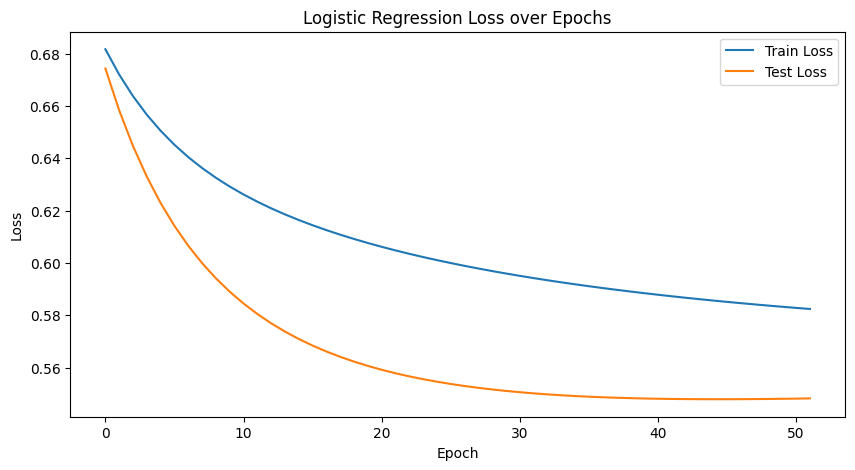

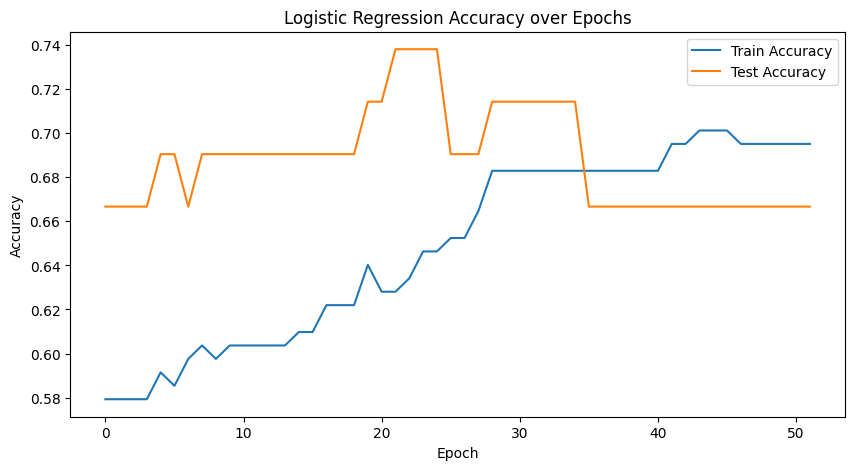

In [67]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Logistic Regression Loss over Epochs')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy over Epochs')
plt.legend()
plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.67      0.64        21
           1       0.63      0.57      0.60        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42

Confusion Matrix:
 [[14  7]
 [ 9 12]]


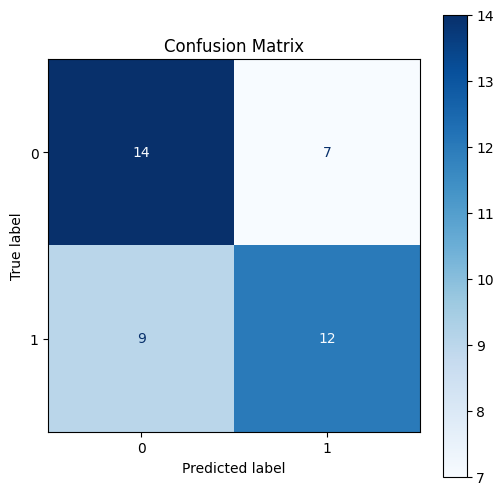

In [68]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()
